In [1]:
import sympy as sp

def heat_equation(u):
    return sp.Eq(
        sp.Derivative(u(x,t), t),
        alpha * sp.Derivative(u(x,t), (x,2))
    )

def finite_difference(eq):
    replacements = {
        sp.Derivative(u(x,t), t): (u(x,t+dt) - u(x,t)) / dt,
        sp.Derivative(u(x,t), (x,2)): (u(x+dx,t) - 2*u(x,t) + u(x-dx,t)) / dx**2
    }
    return eq.xreplace(replacements)



In [2]:

x, t, alpha, dx, dt = sp.symbols('x t alpha dx dt')
u = sp.Function('u')

eq = heat_equation(u)
discrete_eq = finite_difference(eq)


stencil = sp.solve(discrete_eq, u(x, t+dt))[0]
stencil = sp.simplify(stencil)
print(stencil)

(-2*alpha*dt*u(x, t) + alpha*dt*u(-dx + x, t) + alpha*dt*u(dx + x, t) + dx**2*u(x, t))/dx**2


In [3]:
stencil_func = sp.lambdify(
    [alpha, dt, dx, u(x - dx, t), u(x, t), u(x + dx, t)],
    stencil,
    "numpy"
)
stencil_func

<function _lambdifygenerated(alpha, dt, dx, _Dummy_35, _Dummy_37, _Dummy_36)>

In [4]:
import numpy as np
# create mesh

L = 1.0
N = 50 
dx_value = L / (N - 1)
x_values = np.linspace(0, L, N)

alpha = 0.01
dt_value = 0.4 * dx_value ** 2 / alpha
T_end = 5.0
steps = int(T_end / dt_value)

r = alpha * dt_value / dx_value**2
r



0.4

In [5]:
# initial condition
u_num = np.sin(np.pi * x_values)

# boundary condition OR both ends of rod have 0 temperature
u_num[0] = 0.0
u_num[-1] = 0.0


In [6]:
# time step

for step in range(1, steps + 1):
    u_new = u_num.copy()

    u_new[1:-1] = stencil_func(
        alpha, dt_value, dx_value,
        u_num[:-2],   # left
        u_num[1:-1],  # current
        u_num[2:]     # right
    )
    u_new[0] = 0.0
    u_new[-1] = 0.0
    u_num = u_new


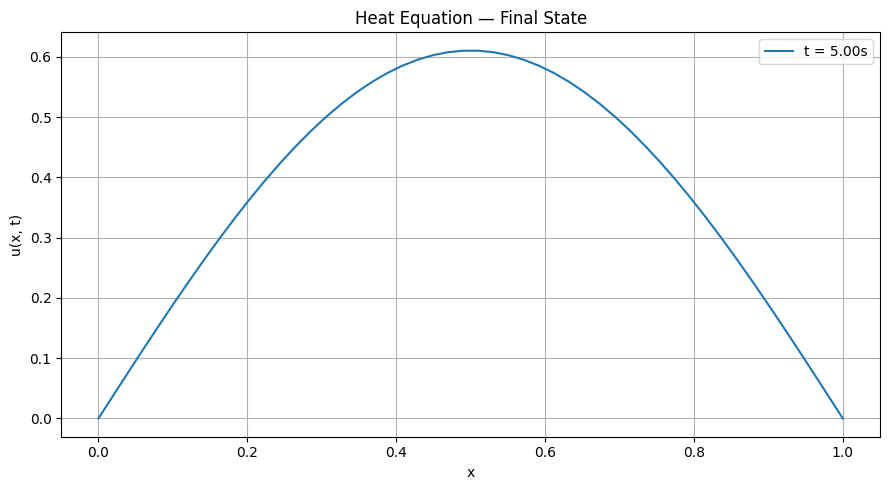

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))
plt.plot(x_values, u_num, label=f"t = {T_end:.2f}s")
plt.xlabel("x")
plt.ylabel("u(x, t)")
plt.title("Heat Equation — Final State")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

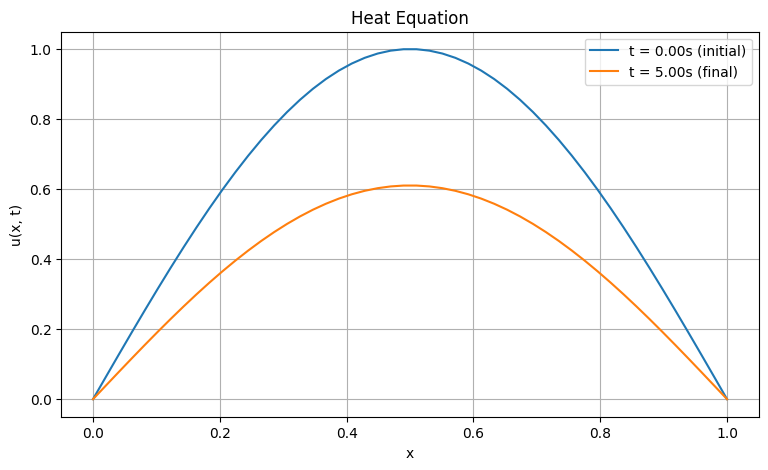

In [9]:
plt.figure(figsize=(9, 5))
plt.plot(x_values, np.sin(np.pi * x_values), label="t = 0.00s (initial)")
plt.plot(x_values, u_num, label=f"t = {T_end:.2f}s (final)")
plt.xlabel("x")
plt.ylabel("u(x, t)")
plt.title("Heat Equation")
plt.legend()
plt.grid(True)
# plt.tight_layout()
plt.show()